**What is prompt?**

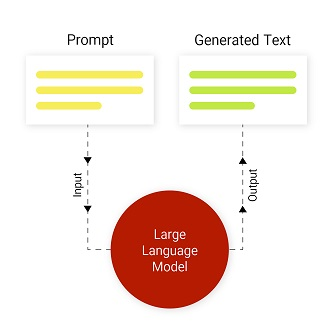

**why is it so important?**


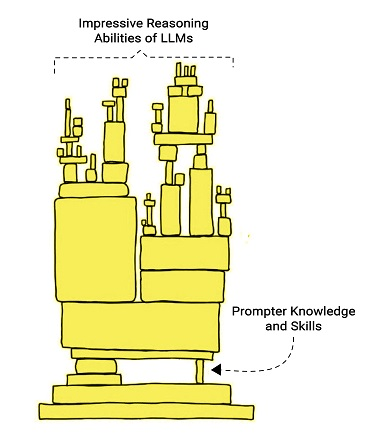

**how can we write better prompts?**


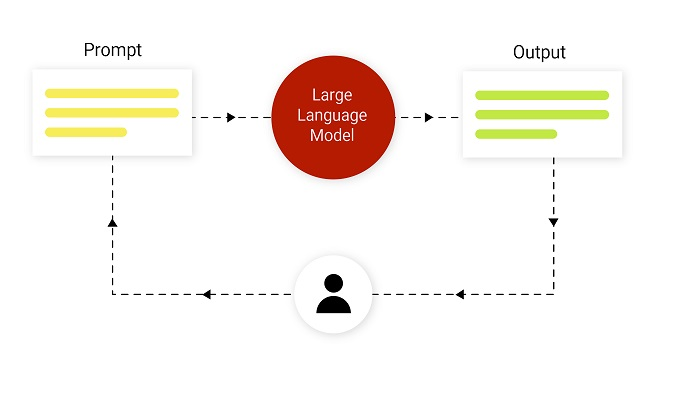

**which providers are integrated to LangChain?**



> [**available llms**](https://integrations.langchain.com/)



**We need api key to get access to models**


> [**access to Google PaLM**](https://developers.generativeai.google/tutorials/setup)

> [**access to Cohere**](https://dashboard.cohere.com/)







**Let s dive into code**


**install some neccessary packages**

In [ ]:
!pip install -q  langchain-openai==0.1.8 langchain_community==0.2.4 tiktoken==0.7.0 langchain==0.2.3
!pip install -q  cohere==5.5.6  langchain_google_genai==1.0.6


In [ ]:
import os
import getpass
os.environ["OPENAI_API_KEY"] = getpass.getpass('your openai api key:')
# os.environ["COHERE_API_KEY"] = getpass.getpass('your cohere api key:')


In [ ]:
# from langchain.llms import OpenAI
from langchain_openai import OpenAI
llm = OpenAI( temperature=0)
llm.model_name

**The input/output for LLMs is simple and easy to understand - a string**

In [ ]:
llm.invoke('who was the president of Iran in 2016?')

In [ ]:
llm.invoke('tell me about Amir Kabir')

In [ ]:
llm.invoke('tell me about Amir Kabir. Provide key dates and events and describe his most imporatnt achievement')

In [ ]:

llm.invoke('tell me about Amir Kabir. Provide 3 bullet points his most imporatnt achievement. your output must to be less than 100 words')

By using prompt templates, developers and researchers can create **well-structured**, **customizable**, and **reusable** prompts that enhance the effectiveness and efficiency of language models

In [ ]:
from langchain.prompts import PromptTemplate

In [ ]:
template = """
 Please translate the following word from {input_language} to {output_language}
 word: {word}"""
prompt = PromptTemplate(template=template, input_variables=["input_language", 'output_language', 'word'])
#Answer: Let's think step by step

In [ ]:
prompt_1 = prompt.format(input_language ='English', output_language='Farsi', word='house')
prompt_1

In [ ]:
print('type of input is:', type(prompt_1))

llm.invoke(prompt_1)

In [ ]:
template = """
You are proficient in {language}, and I would like you to provide a brief definition and two examples
for each vocab. Please keep in mind that I am at a {level} in {language}, so provide two sets of samples for given input:
the first with easy examples and the second with more advanced ones.
input : {input}
Here you go:"""

In [ ]:

prompt = PromptTemplate.from_template(template)
prompt_language = prompt.format(language='English', level='B2', input='ambitious') #obligation, voluntarily
prompt_language

In [ ]:
llm.invoke(prompt_language)

In [ ]:
llm.batch([prompt_language, prompt_1])

In [ ]:
for chunk in llm.stream("tell me about amirkabir. Provide 3 bullet points his most imporatnt achievement"):
    print(chunk, end="", flush=True)

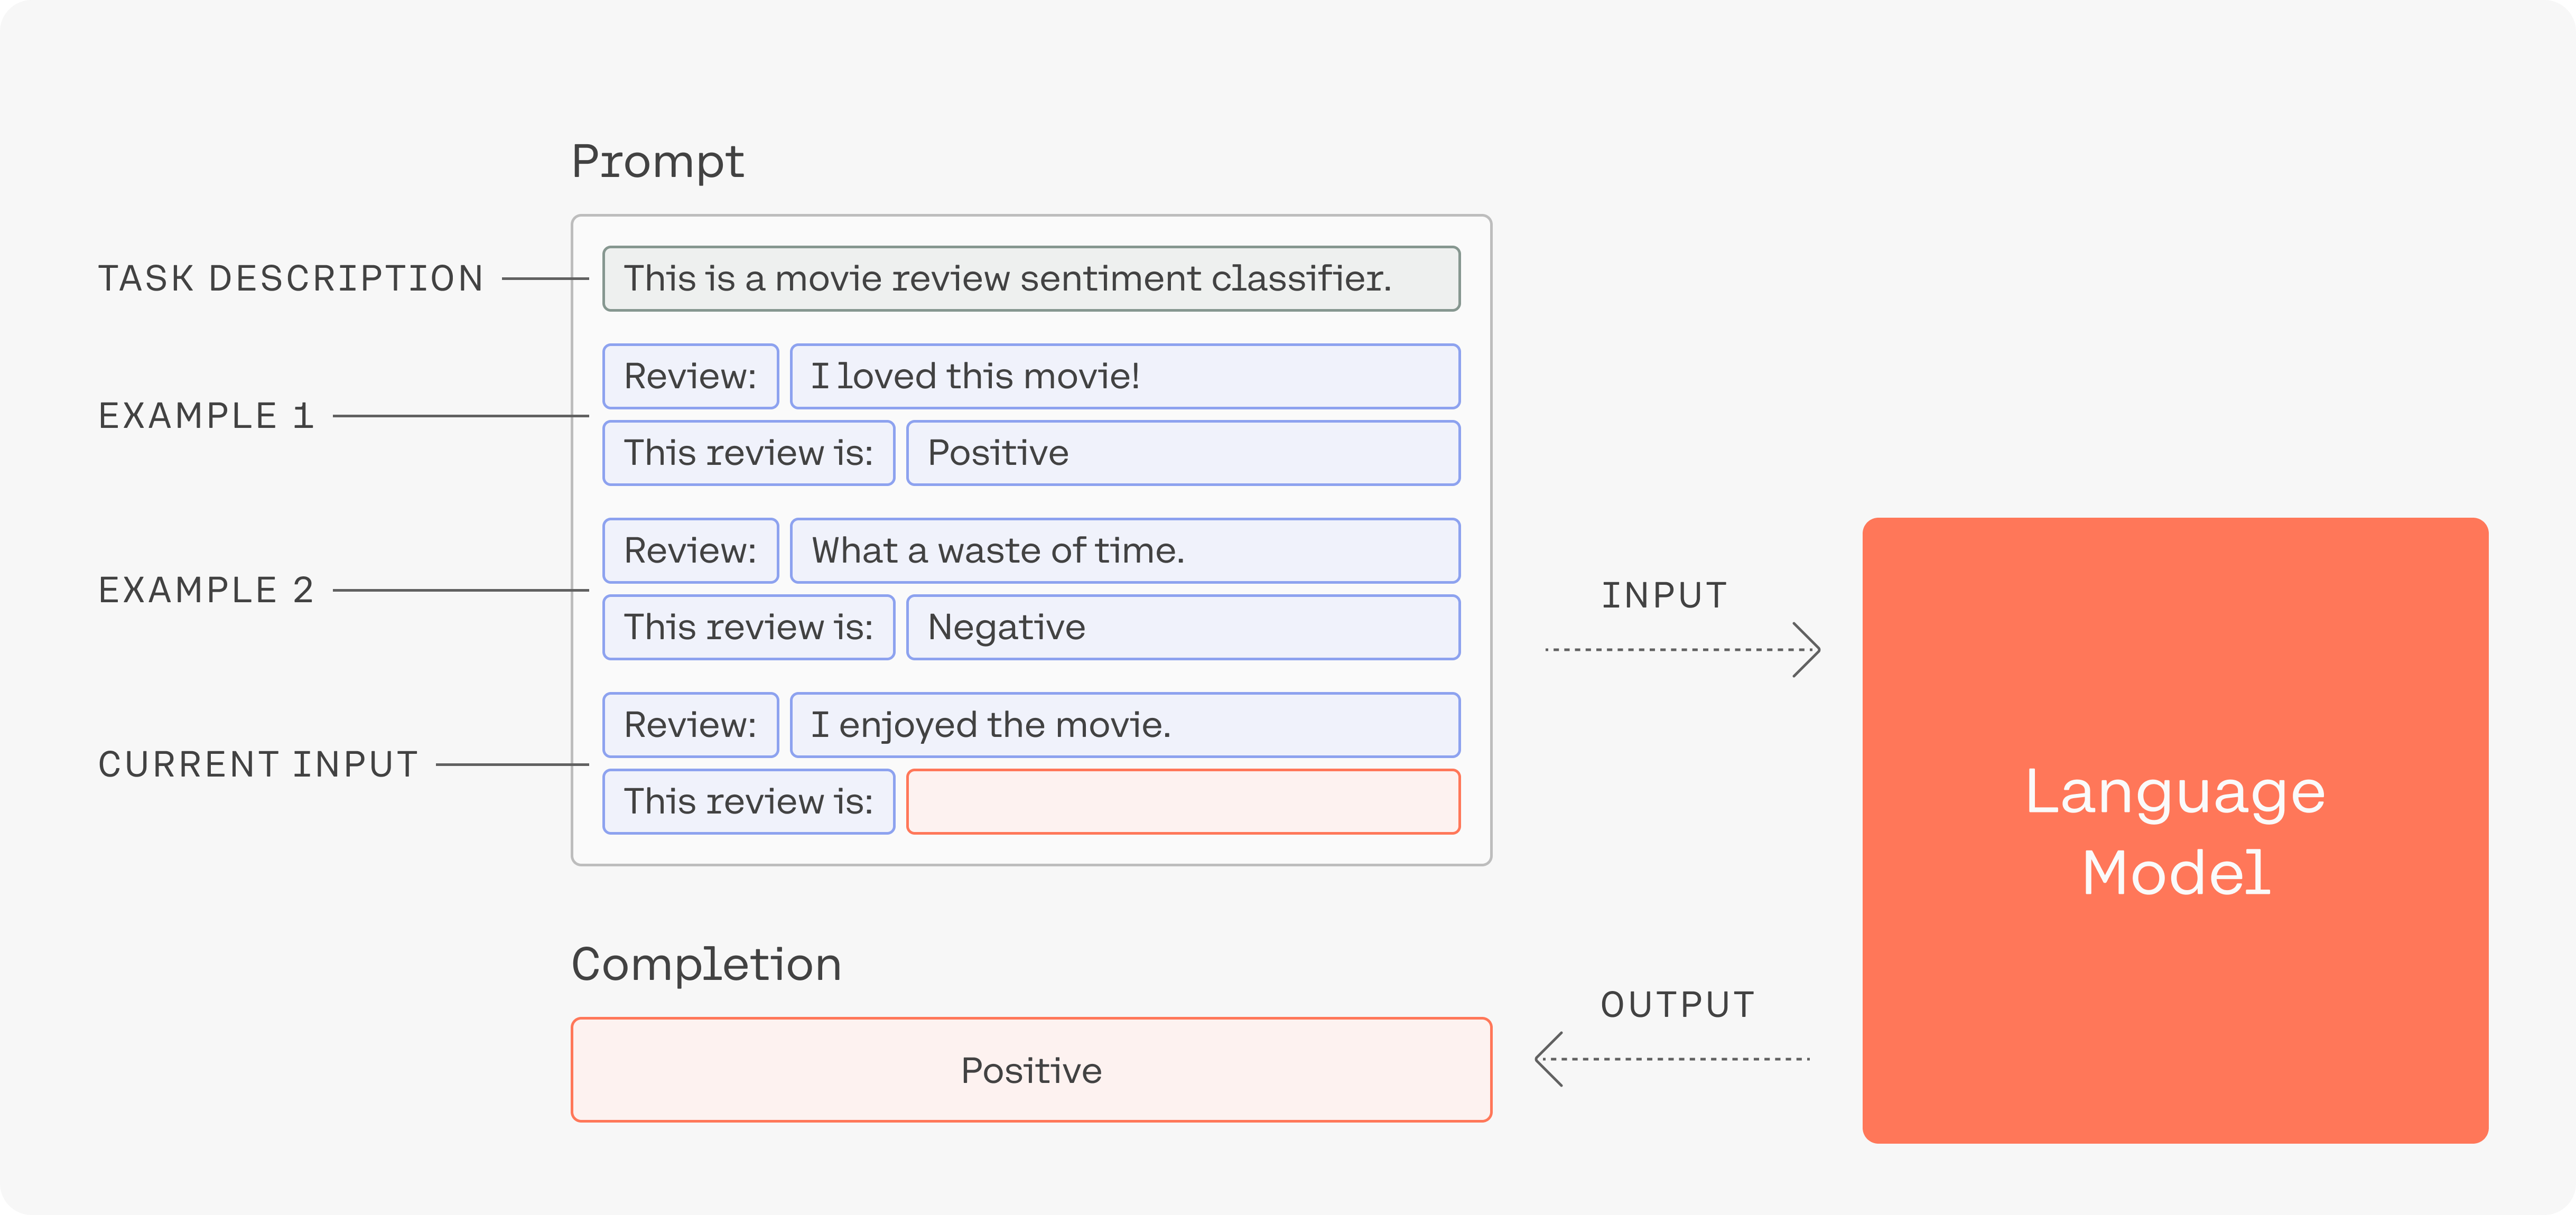

In [ ]:
template = """
This is a movie review sentiment classifier.
Review: "I loved this movie!" This review is positive.
Review: "I don't know, it was ok I guess." This review is neutral.
Review: "What a waste of time, would not recommend this movie." This review is negative.
Review: "بدتر از این نمیشد" . this review is negative.
input review:{review}"""

In [ ]:
i = 0
reviews =['Game of Thrones finally finished, the last episode aptly titled\
 The Long Night and it was a terrible ending, disappointing for fans, causing a collective cringe around the globe.',
 'آخرش خیلی بد تموم شد' ,'اخ اخ منو برد به قدیما این فیلم ممنون از سایت خوبتون❤️' ,
 'هنوزم که هنوز فیلمی رو دستش نیومده' ,'بهترین فیلم دنیاست بنظرم', 'بد نبود']
prompt = PromptTemplate(input_variables=['review'], template=template)
formated_prompt = prompt.format(review= reviews[i])
print('review:', reviews[i])
print(llm.invoke(formated_prompt))

In [ ]:
messages_1 = [

     {'role':'user', 'content':'tell me a joke'},
     {'role':'assistant', 'content':'why did the chicken cross the road'},
      {'role':'user', 'content':'I do not know, why did the chicken cross the road'}

]

system_message = {'role':'system', 'content':'You are an assistant that speaks like Shakespeare.'}


 The input for **Chat models** is a list of **ChatMessages**, and the output is a single **ChatMessage**.

 A **ChatMessage** has two required components:

>**content**: This is the content of the message.

>**role**: This is the role of the entity from which the ChatMessage is coming from.

**LangChain** provides several objects to easily distinguish between different roles:

>**HumanMessage**: A ChatMessage sent from the perspective of the human.

>**AIMessage**: A ChatMessage coming from an AI/assistant.

>**SystemMessage**: A ChatMessage setting the objectives the AI should follow

In [ ]:

from langchain.schema import SystemMessage
python_debugger = SystemMessage(content= 'You will be provided with a piece of Python code, and your task is to find and fix bugs in it.')
twitt_classifier = SystemMessage(content= 'You will be provided with a tweet, and your task is to classify its sentiment as positive, neutral, or negative.')
general_assistant = SystemMessage(content= 'you are a helpful assistant and you always answer questions honestly and concisely.')

In [ ]:
from langchain.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages([
    ("system", "This is a movie review sentiment classifier"),
    ("human", "Review: I loved this movie!"),
    ("ai", "This review is positive"),
    ("human", "Review: I don't know, it was ok I guess."),
    ("ai", "This review is neutral"),
    ("human", "Review: بدتر از این نمی شد"),
    ("ai", "this review is negative"),
    ("human", "{review}"),
])

messages = prompt.format_messages(
    review=reviews[0]
)

In [ ]:
# from langchain.chat_models import ChatOpenAI
from langchain_openai import ChatOpenAI
chat_models = ChatOpenAI(model="gpt-4-1106-preview")

In [ ]:
chat_models.invoke(messages)

In [ ]:
messages
